In [1]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.2 MB/s eta 0:00:00


In [ ]:
!pip install -q nltk

In [2]:
# ============================================================
# CELL 1: INSTALLATION & SETUP
# ============================================================
!pip install imbalanced-learn gensim --quiet

In [3]:
import pandas as pd
import numpy as np
import re
import time
import gc
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from imblearn.over_sampling import SMOTE
from gensim.models import Word2Vec

# Download all NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

print("All libraries installed and imported successfully.")

All libraries installed and imported successfully.


In [5]:
# ============================================================
# CELL 2: DATA LOADING + PREPROCESSING + GLOVE
# ============================================================

# -------------------- DATA LOADING --------------------
MAX_SAMPLES = 3000  # محدود کردن نمونه‌ها برای جلوگیری از کرش رم

def load_twitter(path='Tweets.csv'):
    """Load Twitter US Airlines Sentiment dataset"""
    try:
        df = pd.read_csv(path)
        df = df[['text', 'airline_sentiment']].copy()
        df.columns = ['text', 'sentiment']
        if len(df) > MAX_SAMPLES:
            df = df.sample(n=MAX_SAMPLES, random_state=42)
        print(f"Twitter loaded: {df.shape}")
        return df
    except FileNotFoundError:
        print("Tweets.csv not found! Please upload it to Colab.")
        print("Generating dummy data for demonstration...")
        return generate_dummy_data()

def load_amazon(path='Musical_instruments_reviews.csv'):
    """Load Amazon Musical Instruments Reviews dataset"""
    try:
        df = pd.read_csv(path)
        df = df[['reviewText', 'overall']].dropna().copy()
        df['sentiment'] = df['overall'].apply(
            lambda x: 'positive' if x > 3 else ('negative' if x < 3 else 'neutral')
        )
        df = df[['reviewText', 'sentiment']]
        df.columns = ['text', 'sentiment']
        if len(df) > MAX_SAMPLES:
            df = df.sample(n=MAX_SAMPLES, random_state=42)
        print(f"Amazon loaded: {df.shape}")
        return df
    except FileNotFoundError:
        print("Musical_instruments_reviews.csv not found! Please upload it to Colab.")
        print("Generating dummy data for demonstration...")
        return generate_dummy_data()

def generate_dummy_data():
    """Generate dummy data if real datasets are not available"""
    pos = ["I love this product it is amazing and wonderful"] * 200
    neg = ["This is terrible worst experience ever so bad"] * 200
    neu = ["It was okay nothing special average product"] * 200
    texts = pos + neg + neu
    labels = ['positive'] * 200 + ['negative'] * 200 + ['neutral'] * 200
    return pd.DataFrame({'text': texts, 'sentiment': labels})

# Load datasets
df_twitter = load_twitter()
df_amazon = load_amazon()

# -------------------- TEXT PREPROCESSING --------------------
class TextPreprocessor:
    """
    Text cleaning pipeline:
    1. Remove URLs, mentions, emojis, punctuation
    2. Tokenize
    3. Remove stopwords
    4. Apply Stemming (PorterStemmer)
    5. Apply Lemmatization (WordNetLemmatizer)
    """
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()

    def clean(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = text.encode('ascii', 'ignore').decode('ascii')
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def process(self, text):
        text = self.clean(text)
        tokens = word_tokenize(text)
        tokens = [t for t in tokens if t not in self.stop_words and len(t) > 1]
        processed = []
        for token in tokens:
            stemmed = self.stemmer.stem(token)
            lemma = self.lemmatizer.lemmatize(stemmed)
            processed.append(lemma)
        return " ".join(processed)

# Apply preprocessing
preprocessor = TextPreprocessor()

print("\nPreprocessing Twitter data...")
df_twitter['clean_text'] = df_twitter['text'].apply(preprocessor.process)

print("Preprocessing Amazon data...")
df_amazon['clean_text'] = df_amazon['text'].apply(preprocessor.process)

# Remove empty rows after cleaning
df_twitter = df_twitter[df_twitter['clean_text'].str.strip() != ''].reset_index(drop=True)
df_amazon = df_amazon[df_amazon['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"\nTwitter after cleaning: {df_twitter.shape}")
print(f"Amazon after cleaning: {df_amazon.shape}")

# -------------------- LOAD GLOVE --------------------
print("\nLoading GloVe embeddings (50d - lightweight version)...")
import gensim.downloader as gensim_api

try:
    # نسخه 50 بعدی سبک‌تر است و رم را پر نمی‌کند
    glove_model = gensim_api.load("glove-wiki-gigaword-50")
    GLOVE_DIM = 50
    print(f"GloVe loaded successfully. Dimension: {GLOVE_DIM}")
except Exception as e:
    print(f"GloVe loading failed: {e}")
    print("GloVe will use zero vectors.")
    glove_model = None
    GLOVE_DIM = 50

print("\n=== Setup Complete ===")

Twitter loaded: (3000, 2)
Amazon loaded: (3000, 2)

Preprocessing Twitter data...
Preprocessing Amazon data...

Twitter after cleaning: (2996, 3)
Amazon after cleaning: (3000, 3)

Loading GloVe embeddings (50d - lightweight version)...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded successfully. Dimension: 50

=== Setup Complete ===


In [ ]:
# ============================================================
# CELL 3: FEATURE EXTRACTION + EXPERIMENT RUNNER
# ============================================================

# -------------------- HELPER FUNCTIONS --------------------
def avg_word2vec(tokens, model, vec_size):
    """Calculate average Word2Vec vector for a list of tokens"""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(vec_size)
    return np.mean(vectors, axis=0)

def avg_glove(tokens, model, vec_size):
    """Calculate average GloVe vector for a list of tokens"""
    if model is None:
        return np.zeros(vec_size)
    vectors = [model[w] for w in tokens if w in model]
    if len(vectors) == 0:
        return np.zeros(vec_size)
    return np.mean(vectors, axis=0)

# -------------------- MAIN EXPERIMENT FUNCTION --------------------
MAX_FEATURES = 5000  # محدود کردن تعداد ویژگی‌ها

def run_full_experiment(dataset_name, df):
    """
    Run all 6 feature extraction methods on a single dataset.
    Returns a DataFrame with metrics for each method.
    """
    results = []

    X_text = df['clean_text'].values
    y = df['sentiment'].values

    # 70% Train, 30% Test split
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text, y, test_size=0.30, random_state=42, stratify=y
    )

    # Dictionary of all feature extraction methods
    methods_config = {
        'BOW': {
            'type': 'sklearn',
            'vectorizer': CountVectorizer(max_features=MAX_FEATURES)
        },
        'TF-IDF': {
            'type': 'sklearn',
            'vectorizer': TfidfVectorizer(max_features=MAX_FEATURES)
        },
        'N-Grams(1,2)': {
            'type': 'sklearn',
            'vectorizer': CountVectorizer(ngram_range=(1, 2), max_features=MAX_FEATURES)
        },
        'Hashing Vectorizer': {
            'type': 'hashing',
            'vectorizer': HashingVectorizer(n_features=MAX_FEATURES, alternate_sign=False)
        },
        'Word2Vec': {
            'type': 'embedding',
            'model_type': 'w2v'
        },
        'GloVe': {
            'type': 'embedding',
            'model_type': 'glove'
        }
    }

    for method_name, config in methods_config.items():
        print(f"  [{dataset_name}] Running: {method_name}...", end=" ")
        gc.collect()

        try:
            # ========== STEP 1: Feature Extraction ==========
            if config['type'] == 'sklearn':
                vectorizer = config['vectorizer']
                X_train = vectorizer.fit_transform(X_train_text)
                X_test = vectorizer.transform(X_test_text)

            elif config['type'] == 'hashing':
                vectorizer = config['vectorizer']
                X_train = vectorizer.transform(X_train_text)
                X_test = vectorizer.transform(X_test_text)

            elif config['type'] == 'embedding':
                train_tokens = [text.split() for text in X_train_text]
                test_tokens = [text.split() for text in X_test_text]

                if config['model_type'] == 'w2v':
                    # Train Word2Vec: Skip-gram (sg=1), size=100, window=5
                    w2v = Word2Vec(
                        sentences=train_tokens,
                        vector_size=100, window=5,
                        min_count=1, sg=1, workers=2
                    )
                    X_train = np.array([avg_word2vec(t, w2v, 100) for t in train_tokens])
                    X_test = np.array([avg_word2vec(t, w2v, 100) for t in test_tokens])

                elif config['model_type'] == 'glove':
                    X_train = np.array([avg_glove(t, glove_model, GLOVE_DIM) for t in train_tokens])
                    X_test = np.array([avg_glove(t, glove_model, GLOVE_DIM) for t in test_tokens])

            # ========== STEP 2: SMOTE (Only on Training Data) ==========
            smote = SMOTE(random_state=42)
            X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

            # ========== STEP 3: Random Forest Classifier ==========
            rf = RandomForestClassifier(
                n_estimators=100,
                criterion='gini',
                max_depth=5,
                max_features='sqrt',
                random_state=42,
                n_jobs=1  
            )

            # Training
            start_train = time.time()
            rf.fit(X_train_bal, y_train_bal)
            train_time = time.time() - start_train

            # Prediction
            start_pred = time.time()
            y_pred = rf.predict(X_test)
            pred_time = time.time() - start_pred

            # ========== STEP 4: Evaluation Metrics ==========
            acc = accuracy_score(y_test, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_test, y_pred, average='weighted', zero_division=0
            )

            results.append({
                'Dataset': dataset_name,
                'Method': method_name,
                'Accuracy': round(acc, 4),
                'Precision': round(prec, 4),
                'Recall': round(rec, 4),
                'F1-Score': round(f1, 4),
                'Train Time (s)': round(train_time, 4),
                'Pred Time (s)': round(pred_time, 4)
            })
            print(f"Done! Accuracy: {acc:.4f}")

            # ========== STEP 5: Free Memory ==========
            del X_train, X_test, X_train_bal, y_train_bal, rf
            gc.collect()

        except Exception as e:
            print(f"FAILED! Error: {e}")
            results.append({
                'Dataset': dataset_name,
                'Method': method_name,
                'Accuracy': 0, 'Precision': 0, 'Recall': 0,
                'F1-Score': 0, 'Train Time (s)': 0, 'Pred Time (s)': 0
            })

    return pd.DataFrame(results)

# -------------------- RUN EXPERIMENTS --------------------
extraction_methods = ['BOW', 'TF-IDF', 'N-Grams(1,2)', 'Hashing Vectorizer', 'Word2Vec', 'GloVe']

print("=" * 60)
print("STARTING EXPERIMENTS")
print("=" * 60)

print("\n--- Twitter Dataset ---")
results_twitter = run_full_experiment("Twitter", df_twitter)

print("\n--- Amazon Dataset ---")
results_amazon = run_full_experiment("Amazon", df_amazon)

# Combine all results
all_results = pd.concat([results_twitter, results_amazon], ignore_index=True)

print("\n" + "=" * 60)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("=" * 60)

STARTING EXPERIMENTS

--- Twitter Dataset ---
  [Twitter] Running: BOW... Done! Accuracy: 0.7241
  [Twitter] Running: TF-IDF... Done! Accuracy: 0.6963
  [Twitter] Running: N-Grams(1,2)... Done! Accuracy: 0.6963
  [Twitter] Running: Hashing Vectorizer... Done! Accuracy: 0.7041
  [Twitter] Running: Word2Vec... Done! Accuracy: 0.5662
  [Twitter] Running: GloVe... Done! Accuracy: 0.6363

--- Amazon Dataset ---
  [Amazon] Running: BOW... Done! Accuracy: 0.7522
  [Amazon] Running: TF-IDF... Done! Accuracy: 0.7611
  [Amazon] Running: N-Grams(1,2)... Done! Accuracy: 0.7844
  [Amazon] Running: Hashing Vectorizer... Done! Accuracy: 0.7900
  [Amazon] Running: Word2Vec... Done! Accuracy: 0.4778
  [Amazon] Running: GloVe... Done! Accuracy: 0.5778

ALL EXPERIMENTS COMPLETED SUCCESSFULLY!



PERFORMANCE COMPARISON SUMMARY TABLE


,Dataset,Method,Accuracy,Precision,Recall,F1-Score,Train Time (s),Pred Time (s)
0,Twitter,BOW,0.7241,0.7362,0.7241,0.7292,0.6552,0.0429
1,Twitter,TF-IDF,0.6963,0.7392,0.6963,0.7107,0.8952,0.0384
2,Twitter,"N-Grams(1,2)",0.6963,0.7312,0.6963,0.7079,0.5313,0.0212
3,Twitter,Hashing Vectorizer,0.7041,0.7437,0.7041,0.7169,0.5562,0.0292
4,Twitter,Word2Vec,0.5662,0.5983,0.5662,0.5771,6.0422,0.0285
5,Twitter,GloVe,0.6363,0.6681,0.6363,0.6481,2.3925,0.0135
6,Amazon,BOW,0.7522,0.7898,0.7522,0.7701,0.3092,0.0194
7,Amazon,TF-IDF,0.7611,0.7851,0.7611,0.7728,0.6168,0.0190
8,Amazon,"N-Grams(1,2)",0.7844,0.7921,0.7844,0.7882,0.3121,0.0199
9,Amazon,Hashing Vectorizer,0.7900,0.7865,0.7900,0.7882,0.9165,0.0262


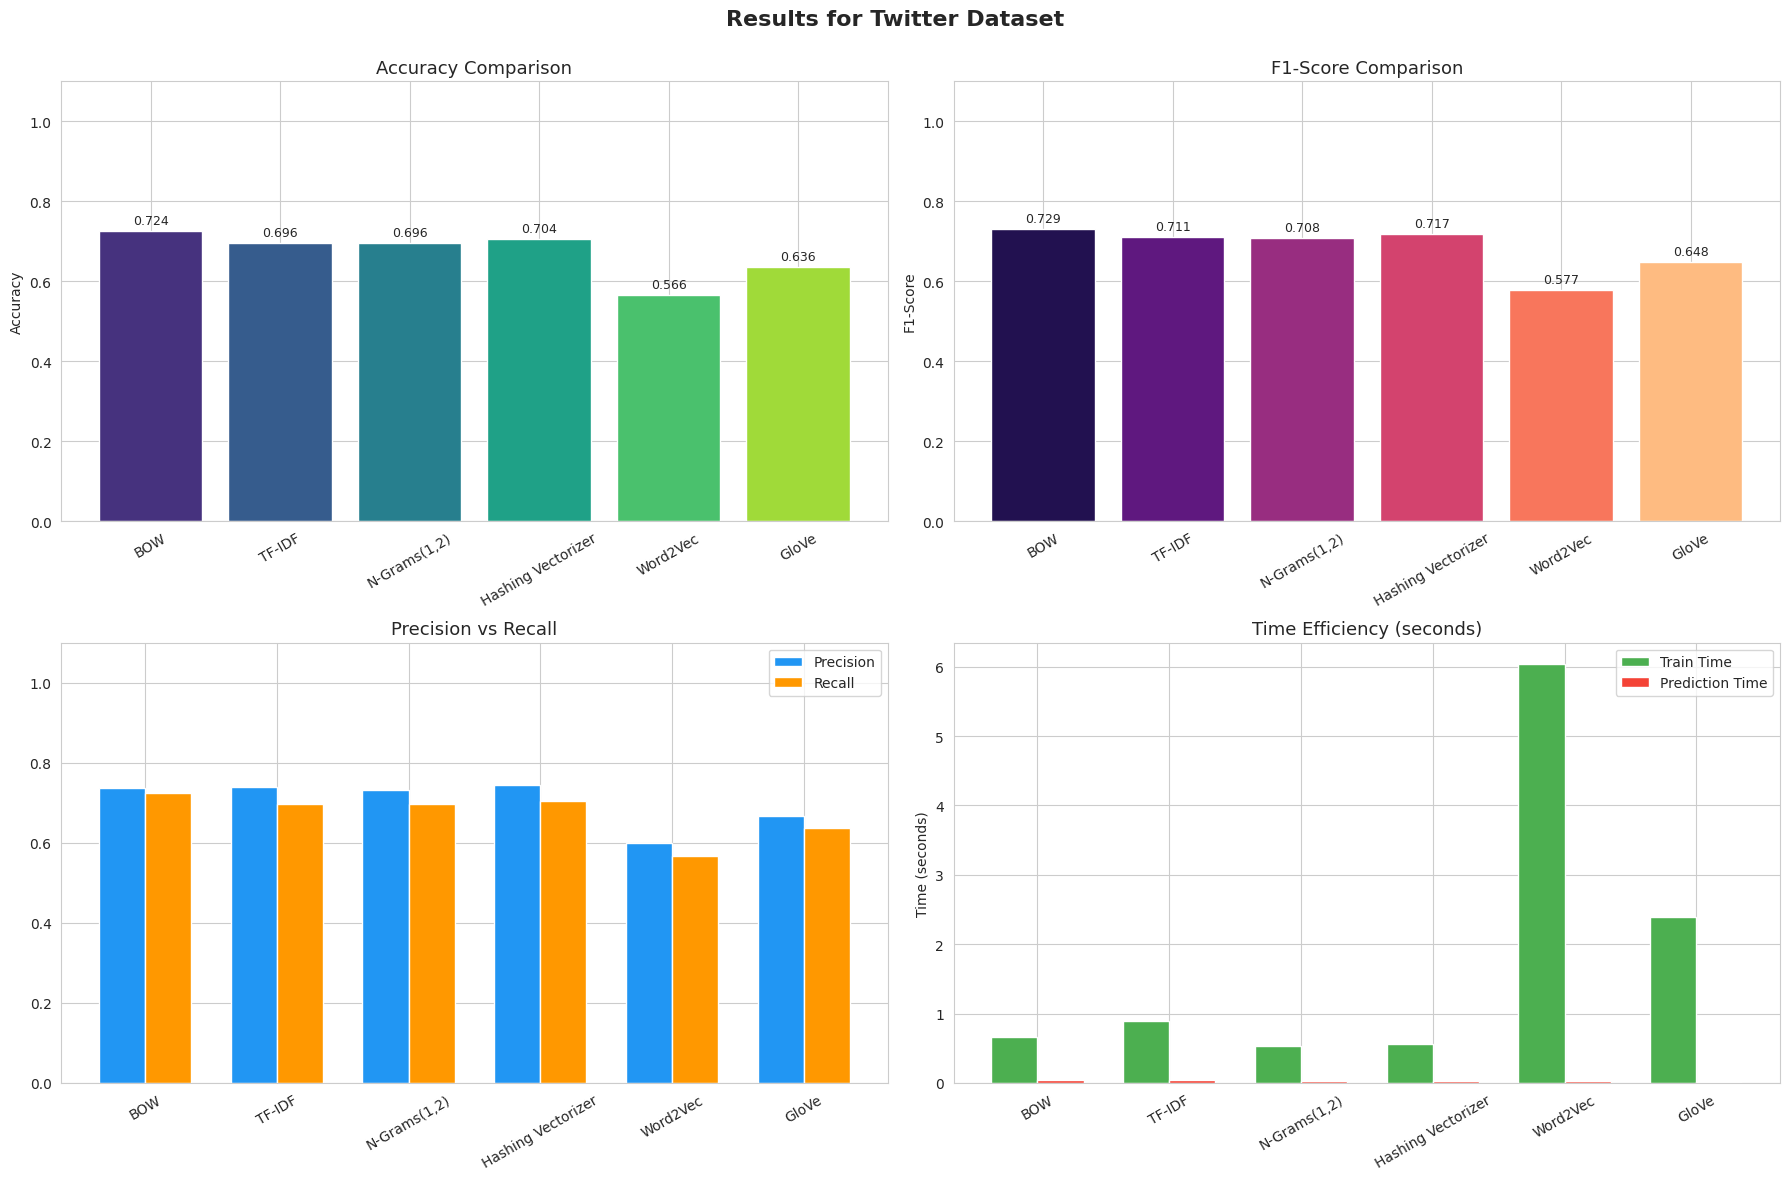

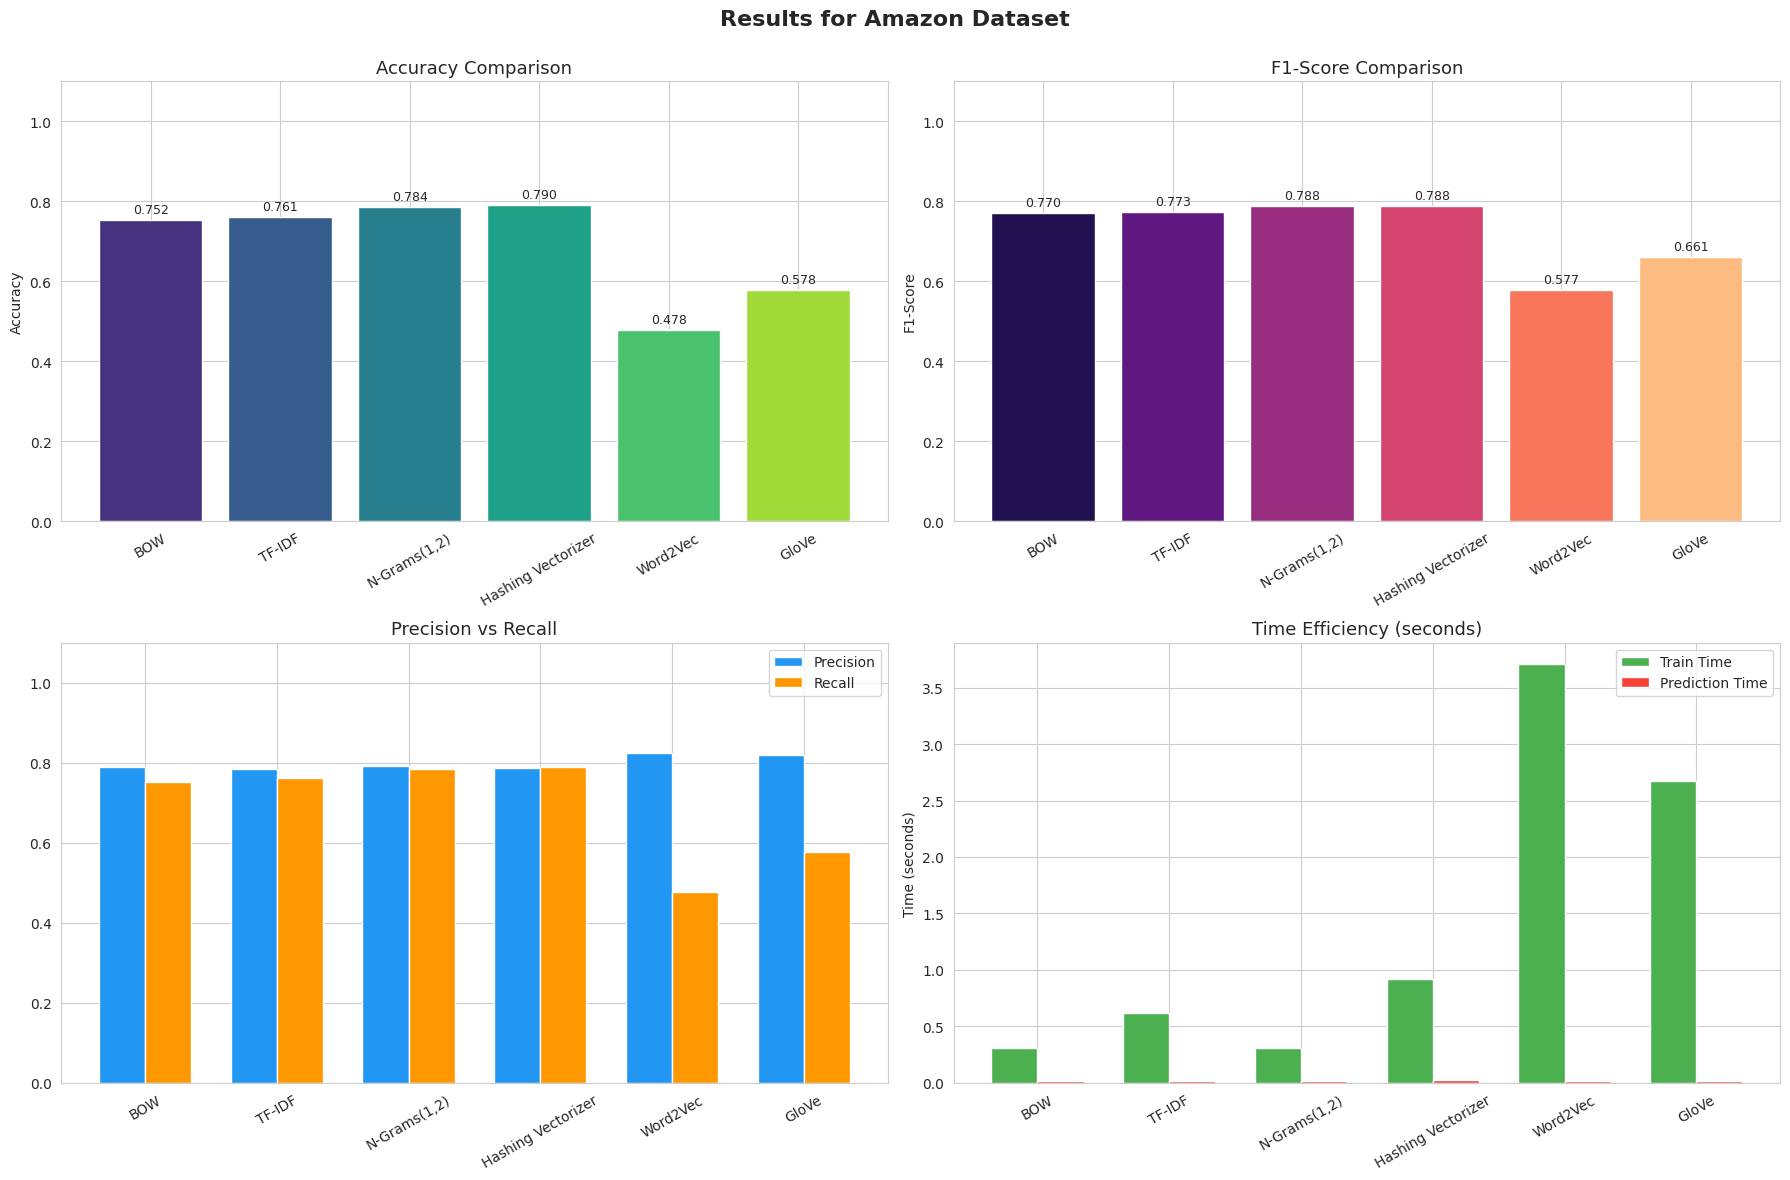


BEST PERFORMING METHOD PER DATASET

Twitter:
  Best Method:  BOW
  Accuracy:     0.7241
  Precision:    0.7362
  Recall:       0.7241
  F1-Score:     0.7292
  Train Time:   0.6552s

Amazon:
  Best Method:  Hashing Vectorizer
  Accuracy:     0.7900
  Precision:    0.7865
  Recall:       0.7900
  F1-Score:     0.7882
  Train Time:   0.9165s


In [7]:
# ============================================================
# CELL 4: RESULTS TABLE + VISUALIZATIONS
# ============================================================

# -------------------- SUMMARY TABLE --------------------
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON SUMMARY TABLE")
print("=" * 80)
display(all_results)

# -------------------- VISUALIZATION --------------------
datasets_list = all_results['Dataset'].unique()

for ds_name in datasets_list:
    subset = all_results[all_results['Dataset'] == ds_name]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Results for {ds_name} Dataset', fontsize=16, fontweight='bold')

    # Plot 1: Accuracy Comparison
    bars1 = axes[0, 0].bar(subset['Method'], subset['Accuracy'], color=sns.color_palette("viridis", len(subset)))
    axes[0, 0].set_title('Accuracy Comparison', fontsize=13)
    axes[0, 0].set_ylim(0, 1.1)
    axes[0, 0].set_ylabel('Accuracy')
    for bar in bars1:
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    axes[0, 0].tick_params(axis='x', rotation=30)

    # Plot 2: F1-Score Comparison
    bars2 = axes[0, 1].bar(subset['Method'], subset['F1-Score'], color=sns.color_palette("magma", len(subset)))
    axes[0, 1].set_title('F1-Score Comparison', fontsize=13)
    axes[0, 1].set_ylim(0, 1.1)
    axes[0, 1].set_ylabel('F1-Score')
    for bar in bars2:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    axes[0, 1].tick_params(axis='x', rotation=30)

    # Plot 3: Precision & Recall
    x_pos = np.arange(len(subset))
    width = 0.35
    axes[1, 0].bar(x_pos - width/2, subset['Precision'].values, width, label='Precision', color='#2196F3')
    axes[1, 0].bar(x_pos + width/2, subset['Recall'].values, width, label='Recall', color='#FF9800')
    axes[1, 0].set_title('Precision vs Recall', fontsize=13)
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(subset['Method'].values, rotation=30)
    axes[1, 0].set_ylim(0, 1.1)
    axes[1, 0].legend()

    # Plot 4: Time Efficiency
    x_pos2 = np.arange(len(subset))
    axes[1, 1].bar(x_pos2 - width/2, subset['Train Time (s)'].values, width, label='Train Time', color='#4CAF50')
    axes[1, 1].bar(x_pos2 + width/2, subset['Pred Time (s)'].values, width, label='Prediction Time', color='#F44336')
    axes[1, 1].set_title('Time Efficiency (seconds)', fontsize=13)
    axes[1, 1].set_xticks(x_pos2)
    axes[1, 1].set_xticklabels(subset['Method'].values, rotation=30)
    axes[1, 1].legend()
    axes[1, 1].set_ylabel('Time (seconds)')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# -------------------- BEST METHOD --------------------
print("\n" + "=" * 60)
print("BEST PERFORMING METHOD PER DATASET")
print("=" * 60)
for ds_name in datasets_list:
    subset = all_results[all_results['Dataset'] == ds_name]
    best_row = subset.loc[subset['Accuracy'].idxmax()]
    print(f"\n{ds_name}:")
    print(f"  Best Method:  {best_row['Method']}")
    print(f"  Accuracy:     {best_row['Accuracy']:.4f}")
    print(f"  Precision:    {best_row['Precision']:.4f}")
    print(f"  Recall:       {best_row['Recall']:.4f}")
    print(f"  F1-Score:     {best_row['F1-Score']:.4f}")
    print(f"  Train Time:   {best_row['Train Time (s)']:.4f}s")